# 03. Modelo de Texto

Generación de embeddings con sentence-transformers y baseline TF-IDF.

In [13]:
import sys, os
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from src.text_features import TextFeatureExtractor
from src.evaluation import temporal_train_test_split

## 1. Cargar datos procesados

In [14]:
restaurants = pd.read_csv('../data/processed/restaurants.csv')
reviews = pd.read_csv('../data/processed/reviews.csv', parse_dates=['date'])
print(f'{len(restaurants)} restaurantes | {len(reviews)} reviews')

1161 restaurantes | 74984 reviews


## 2. Split temporal train/test

In [15]:
train_reviews, test_reviews = temporal_train_test_split(reviews, test_fraction=0.2)

Train: 61870 reviews | Test: 13114 reviews


## 3. Generar embeddings de texto (o cargar si ya existen)

In [16]:
import os

EMB_FILE = 'text_embeddings.npz'
EMB_PATH = f'../data/embeddings/{EMB_FILE}'

if os.path.exists(EMB_PATH):
    print('Loading cached text embeddings...')
    text_embeddings = TextFeatureExtractor.load(EMB_FILE)
else:
    extractor = TextFeatureExtractor(model_name='all-MiniLM-L6-v2', mode='dense')
    text_embeddings = extractor.fit_transform(train_reviews)
    extractor.save(text_embeddings, EMB_FILE)

print(f'Embeddings: {len(text_embeddings)} restaurantes, dim={next(iter(text_embeddings.values())).shape[0]}')

Loading cached text embeddings...
Embeddings: 1151 restaurantes, dim=384


## 4. Visualización con PCA

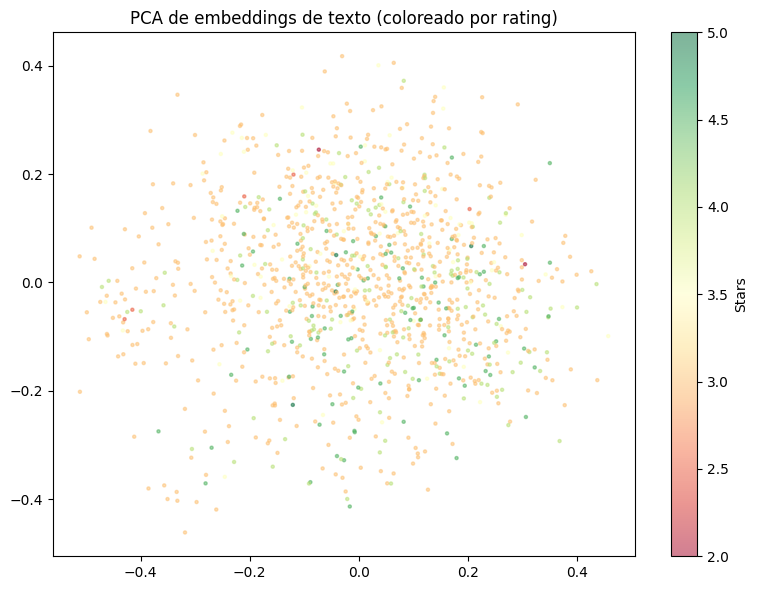

In [17]:
ids = list(text_embeddings.keys())
matrix = np.stack([text_embeddings[i] for i in ids])

pca = PCA(n_components=2)
coords = pca.fit_transform(matrix)

# Colorear por rating
rating_map = restaurants.set_index('business_id')['stars'].to_dict()
colors = [rating_map.get(bid, 3.0) for bid in ids]

plt.figure(figsize=(8, 6))
sc = plt.scatter(coords[:, 0], coords[:, 1], c=colors, cmap='RdYlGn', alpha=0.5, s=5)
plt.colorbar(sc, label='Stars')
plt.title('PCA de embeddings de texto (coloreado por rating)')
plt.tight_layout()

## 5. Ejemplo de recomendación y evaluación

In [18]:
ids = list(text_embeddings.keys())
matrix_arr = np.stack([text_embeddings[i] for i in ids])
id_to_idx = {bid: i for i, bid in enumerate(ids)}

sample_id = ids[0]
sample_name = restaurants[restaurants['business_id'] == sample_id]['name'].values
print(f'Base restaurant: {sample_name}')

query = matrix_arr[id_to_idx[sample_id]].reshape(1, -1)
sims = cosine_similarity(query, matrix_arr)[0]
sims[id_to_idx[sample_id]] = -1
for i in np.argsort(sims)[::-1][:5]:
    name = restaurants[restaurants['business_id'] == ids[i]]['name'].values
    print(f'  {name} - similarity: {sims[i]:.3f}')

Base restaurant: ['IndeBlue Modern Indian Food & Spirits']
  ['Nomad Roman Pizza'] - similarity: 0.750
  ['The Love'] - similarity: 0.726
  [] - similarity: 0.716
  [] - similarity: 0.715
  [] - similarity: 0.705
